# <a id='toc1_'></a>[Laboratorio 1 - Exploración, preparación y regresión lineal](#toc0_)
*Presentado por:*
- Shaiel Jimenez - 202323846

- Juan Esteban Triviño - 202315338

*ISIS2611 - Aprendizaje de Máquina / Sección 5*

*Profesor: Rubén Manrique*

**Table of contents**<a id='toc0_'></a>    
- [Laboratorio 1 - Exploración, preparación y regresión lineal](#toc1_)    
- [Introducción](#toc2_)    
  - [Resumen de los pasos realizados](#toc2_1_)    
- [Exploración de los datos](#toc3_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc2_'></a>[Introducción](#toc0_)

Este laboratorio aborda el caso del Instituto AlpesPlanck, que
registra variables meteorológicas en su estación de Jena, Alemania, y busca predecir
la temperatura máxima del día siguiente para anticipar condiciones que puedan derivar
en incendios forestales o en fenómenos como "El Niño" y "La Niña". A partir de estos
datos, en este trabajo se aplica el ciclo de machine learning para explorar y preparar
la información disponible, construir y comparar dos modelos de regresión lineal con
distintas estrategias de preparación, evaluar su desempeño mediante las métricas RMSE,
MAE y R², e identificar las variables meteorológicas que más aportan a la predicción,
con el fin de generar conocimiento útil para la toma de decisiones frente a este tipo
de fenómenos climáticos.

## <a id='toc2_1_'></a>[Resumen de los pasos realizados](#toc0_)

*(Esta sección se completa al finalizar el laboratorio, resumiendo brevemente las
decisiones tomadas en cada etapa del ciclo de ML.)*

- **Exploración de datos:** nulos revisados (~2.4-3.7% por columna), duplicados de fecha
  identificados y resueltos, valores categóricos inconsistentes normalizados (`mes`,
  `estacion_anio`, `sector_viento`), errores de escala corregidos (`presion_media`,
  `humedad_media`, `humedad_min`), outliers físicamente imposibles eliminados
  (ráfaga negativa, componente de viento fuera de rango, registros/día > 144),
  correlación de variables numéricas con el target revisada.
- **Preparación de datos:** split train/test (75/25, `random_state=42`) hecho *antes* de
  imputar, para evitar fuga de datos; imputación de nulos (mediana/moda) ajustada solo
  con `X_train`.
- **Modelo 1 — estrategia de preparación:** *[pendiente]*
- **Modelo 2 — estrategia de preparación:** *[pendiente]*
- **Evaluación comparativa:** *[pendiente]*
- **Variables más importantes:** *[pendiente]*
- **Predicciones sobre datos de prueba:** *[pendiente]*

# <a id='toc3_'></a>[Exploración de los datos](#toc0_)

In [1]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Carga Inicial de datos

In [2]:
# cargar los datos empleando pandas
df = pd.read_csv('data/Datos Lab 1.csv')
data = df.copy()

df.shape 

(2576, 27)

## Revision y tratamiento de datos

In [3]:
((data.isnull().sum()/data.shape[0])).sort_values(ascending=False)


temp_max_manana      0.036879
viento_min           0.035326
mes                  0.034161
estacion_anio        0.034161
anio                 0.033385
humedad_max          0.033385
viento_media         0.033385
viento_max           0.031444
presion_desv         0.031056
humedad_min          0.031056
viento_norte         0.031056
rafaga_desv          0.030668
direccion_viento     0.030668
rafaga_media         0.030280
registros_del_dia    0.029891
presion_media        0.029115
humedad_media        0.028727
presion_min          0.028727
rafaga_max           0.028339
rafaga_min           0.027950
viento_desv          0.027950
fecha                0.027950
sector_viento        0.027562
dia_del_anio         0.026398
viento_este          0.024845
presion_max          0.024845
humedad_desv         0.023680
dtype: float64

In [4]:

# Si fecha es nulo se podria eliminar dado que no tiene sentido imputar una fecha, ademas de que es una columna que no aporta informacion para el analisis de los datos.

data = data.dropna(subset=['fecha'])

# Agrupar columnas numericas y categoricas (se usan mas adelante)

num_cols = data.select_dtypes(include=np.number).columns

cat_cols = data.select_dtypes(include='object').columns

# NOTA IMPORTANTE: la imputación estadística (mediana / moda) de estas columnas
# se difiere hasta DESPUÉS de hacer el split train/test. Si imputáramos ahora,
# sobre el 100% de los datos, la mediana/moda usada para llenar valores en el
# futuro conjunto de train ya habría "visto" filas que terminan en test → fuga
# de datos. La imputación real se hace más abajo, ajustando el imputador
# únicamente con datos de entrenamiento.


/var/folders/l9/8qd8kqn906q_s4lmvfrxlyfc0000gn/T/ipykernel_43751/3769417702.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = data.select_dtypes(include='object').columns


In [5]:
((data.isnull().sum()/data.shape[0])).sort_values(ascending=False)

temp_max_manana      0.037141
viento_min           0.035144
mes                  0.034744
estacion_anio        0.034744
viento_media         0.033546
anio                 0.033147
humedad_max          0.031949
viento_max           0.031550
presion_desv         0.031150
rafaga_desv          0.030751
registros_del_dia    0.030751
direccion_viento     0.030751
rafaga_media         0.030351
viento_norte         0.029952
humedad_min          0.029952
presion_media        0.029553
humedad_media        0.029553
presion_min          0.029153
rafaga_min           0.027955
viento_desv          0.027955
sector_viento        0.027556
rafaga_max           0.027157
dia_del_anio         0.026757
presion_max          0.024361
viento_este          0.023962
humedad_desv         0.023962
fecha                0.000000
dtype: float64

## Corrección de inconsistencias en variables categóricas

Al revisar los valores únicos de `mes`, `estacion_anio` y `sector_viento` se encontró que
**no son datos limpios**, aunque no tengan valores nulos:

- **`mes`**: 60 valores únicos para 12 meses reales (mayúsculas/minúsculas y español/inglés
  mezclados: `APRIL`, `Apr`, `abril`, `april`, `April`...).
- **`estacion_anio`**: 28 valores para 4 estaciones. Incluye errores de tipeo
  (`primaveraa`, `berano`, `invernio`, `verno`), espacios extra, y valores que **no son
  estaciones válidas**: `'East'` (una dirección de viento mal ubicada en esta columna),
  `'Estacion_Desconocida'` (un valor centinela explícito de dato desconocido) y
  `'VERANO_INVIERNO'` (una combinación sin sentido). Estos tres casos se tratan como
  **valores faltantes** en vez de forzar un mapeo arbitrario, porque no hay forma
  confiable de inferir la estación real a partir de ellos.
- **`sector_viento`**: 31 valores para 8 direcciones cardinales, mismo problema de formato.

Se normalizan a un conjunto reducido y consistente de categorías antes de continuar,
porque de lo contrario el imputador de moda (`most_frequent`) y cualquier encoding
posterior tratarían, por ejemplo, `"april"` y `"APRIL"` como categorías distintas.

In [6]:
import re

def normaliza(s):
    if pd.isna(s):
        return s
    s = str(s).strip().lower()
    s = re.sub(r'[^a-záéíóúñ]', '', s)
    return s

# --- mes: 12 meses en español, sin importar idioma/formato de entrada ---
meses_map = {
    'enero': 'enero', 'jan': 'enero', 'january': 'enero',
    'febrero': 'febrero', 'feb': 'febrero', 'february': 'febrero',
    'marzo': 'marzo', 'mar': 'marzo', 'march': 'marzo',
    'abril': 'abril', 'apr': 'abril', 'april': 'abril',
    'mayo': 'mayo', 'may': 'mayo',
    'junio': 'junio', 'jun': 'junio', 'june': 'junio',
    'julio': 'julio', 'jul': 'julio', 'july': 'julio',
    'agosto': 'agosto', 'aug': 'agosto', 'august': 'agosto',
    'septiembre': 'septiembre', 'sep': 'septiembre', 'sept': 'septiembre', 'september': 'septiembre',
    'octubre': 'octubre', 'oct': 'octubre', 'october': 'octubre',
    'noviembre': 'noviembre', 'nov': 'noviembre', 'november': 'noviembre',
    'diciembre': 'diciembre', 'dec': 'diciembre', 'december': 'diciembre',
}
data['mes'] = data['mes'].apply(normaliza).map(meses_map)

# --- estacion_anio: 4 estaciones en español; garbage -> NaN (se imputa después) ---
estacion_map = {
    'invierno': 'invierno', 'winter': 'invierno', 'invernio': 'invierno', 'inverano': 'invierno',
    'primavera': 'primavera', 'spring': 'primavera', 'primav': 'primavera', 'primaveraa': 'primavera',
    'verano': 'verano', 'summer': 'verano', 'berano': 'verano', 'verno': 'verano',
    'otono': 'otono', 'autumn': 'otono', 'fall': 'otono', 'otoño': 'otono',
}
data['estacion_anio'] = data['estacion_anio'].apply(normaliza).map(estacion_map)  # no match -> NaN

# --- sector_viento: 8 puntos cardinales en español abreviado ---
sector_map = {
    'n': 'N', 'north': 'N', 'norte': 'N',
    'ne': 'NE', 'northeast': 'NE', 'noreste': 'NE',
    'e': 'E', 'east': 'E', 'este': 'E',
    'se': 'SE', 'southeast': 'SE', 'sureste': 'SE',
    's': 'S', 'south': 'S', 'sur': 'S',
    'so': 'SO', 'southwest': 'SO', 'suroeste': 'SO',
    'o': 'O', 'west': 'O', 'oeste': 'O',
    'no': 'NO', 'northwest': 'NO', 'noroeste': 'NO',
}
data['sector_viento'] = data['sector_viento'].apply(normaliza).map(sector_map)

print('mes:', sorted(data['mes'].dropna().unique()))
print()
print('estacion_anio:', sorted(data['estacion_anio'].dropna().unique()))
print('  -> nuevos NaN por valores no reconocidos:', data['estacion_anio'].isna().sum())
print()
print('sector_viento:', sorted(data['sector_viento'].dropna().unique()))

mes: ['abril', 'agosto', 'diciembre', 'enero', 'febrero', 'julio', 'junio', 'marzo', 'mayo', 'noviembre', 'octubre', 'septiembre']

estacion_anio: ['invierno', 'otono', 'primavera', 'verano']
  -> nuevos NaN por valores no reconocidos: 255

sector_viento: ['E', 'N', 'NE', 'NO', 'O', 'S', 'SE', 'SO']


## Corrección de errores de magnitud/escala en variables numéricas

Además de nulos y categorías inconsistentes, hay valores numéricos con **errores de escala**
(no son nulos, así que el imputador no los toca, pero son incorrectos):

- **`presion_media`**: 6 filas con valores como `9928.77` en un rango donde el resto de la
  columna está entre 900-1050 (hPa). Es consistente con un error de captura que agregó un
  dígito de más (`9928.77` → `992.877`). Se corrige dividiendo entre 10 los valores > 5000.
- **`humedad_media`** y **`humedad_min`**: **776 y 621 filas (30% y 24% del dataset)** con
  valores ≤ 1, cuando el resto de la columna está en escala de porcentaje (0-100). Esto no es
  un par de casos aislados: es sistemático, muy probablemente un subconjunto de los datos
  quedó guardado como fracción (0.91) en vez de porcentaje (91.0) al fusionar fuentes. Se
  corrige multiplicando por 100 los valores ≤ 1.

Ambas correcciones se basan en el rango físicamente plausible de cada variable, no en un
criterio estadístico de outliers (evita confundir "dato mal capturado" con "día real de
clima extremo").

In [7]:
print('Antes de corregir:')
print('  presion_media > 5000:', (data['presion_media'] > 5000).sum())
print('  humedad_media <= 1  :', (data['humedad_media'] <= 1).sum())
print('  humedad_min <= 1    :', (data['humedad_min'] <= 1).sum())

mask_presion = data['presion_media'] > 5000
data.loc[mask_presion, 'presion_media'] = data.loc[mask_presion, 'presion_media'] / 10

mask_hum_media = data['humedad_media'] <= 1
data.loc[mask_hum_media, 'humedad_media'] = data.loc[mask_hum_media, 'humedad_media'] * 100

mask_hum_min = data['humedad_min'] <= 1
data.loc[mask_hum_min, 'humedad_min'] = data.loc[mask_hum_min, 'humedad_min'] * 100

print('\nDespués de corregir:')
print('  presion_media > 5000:', (data['presion_media'] > 5000).sum())
print('  humedad_media <= 1  :', (data['humedad_media'] <= 1).sum())
print('  humedad_min <= 1    :', (data['humedad_min'] <= 1).sum())
print()
print(data[['presion_media', 'humedad_media', 'humedad_min']].describe())

Antes de corregir:
  presion_media > 5000: 6
  humedad_media <= 1  : 755
  humedad_min <= 1    : 605

Después de corregir:
  presion_media > 5000: 0
  humedad_media <= 1  : 26
  humedad_min <= 1    : 0

       presion_media  humedad_media  humedad_min
count    2430.000000    2430.000000  2429.000000
mean      989.136877      75.217926    59.928945
std         8.036440      13.891347    18.195759
min       948.996000       0.466265     1.003387
25%       984.278675      67.475750    45.550000
50%       989.432450      76.818800    58.890000
75%       994.373150      84.504300    72.500000
max      1011.653800     100.000000   103.311405


## Duplicados

In [8]:
n_duplicados = int(data.duplicated(keep=False).sum())
print(f"Número de registros duplicados: {n_duplicados}")

# Eliminar registros duplicados
data = data.drop_duplicates(keep='first')

n_duplicados_rev = int(data.duplicated(keep=False).sum())
print(f"Número de registros duplicados: {n_duplicados_rev}")

# ¿Hay fechas que se repiten?
dup_fechas = (data['fecha'].value_counts()
                            .loc[lambda s: s > 1]
                            .sort_values(ascending=False))
print(f"Fechas duplicadas: {len(dup_fechas)}")

for fecha, n in dup_fechas.items():
    print(f"Fecha={fecha} → {n} apariciones")



    

    


Número de registros duplicados: 8
Número de registros duplicados: 0
Fechas duplicadas: 14
Fecha=2009-03-05 → 2 apariciones
Fecha=2009-05-02 → 2 apariciones
Fecha=2009-12-08 → 2 apariciones
Fecha=2010-08-14 → 2 apariciones
Fecha=2010-10-25 → 2 apariciones
Fecha=2012-10-04 → 2 apariciones
Fecha=2012-10-06 → 2 apariciones
Fecha=2012-11-22 → 2 apariciones
Fecha=2013-01-02 → 2 apariciones
Fecha=2013-05-29 → 2 apariciones
Fecha=2015-01-07 → 2 apariciones
Fecha=2015-02-03 → 2 apariciones
Fecha=2015-05-11 → 2 apariciones
Fecha=2015-12-07 → 2 apariciones


In [9]:
data['fecha'] = pd.to_datetime(data['fecha'])

# Filas donde el año no coincide con la fecha
inconsistentes = data[data['anio'] != data['fecha'].dt.year]
print(inconsistentes.shape[0])
inconsistentes



83


,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
25,2009-01-26,977.2310,975.000000,980.89,1.7438,96.5639,95.20,97.5,0.5982,1.40990,...,1.0684,0.3670,18.9574,144.0,NaN,26.0,verano,septiembre,N,-1.04
30,2009-01-31,994.3756,989.950000,997.42,2.0522,88.4403,73.30,94.4,5.4441,2.58660,...,1.9530,1.6026,39.3705,144.0,NaN,31.0,invierno,abril,NE,NaN
121,2009-05-02,998.1189,995.990000,999.41,0.9205,77.5000,51.09,99.6,18.9020,1.84440,...,NaN,0.4668,23.7431,144.0,NaN,122.0,primavera,octubre,NaN,20.89
132,2009-05-13,992.3840,989.590000,995.05,1.8406,59.6700,44.88,75.7,10.2773,2.52420,...,1.3270,1.3113,44.6575,144.0,NaN,133.0,primavera,julio,NE,17.84
163,2009-06-13,993.6042,992.800000,994.35,0.4078,55.8449,30.51,88.2,18.8033,6.93864,...,-0.2299,-1.5106,261.3481,144.0,NaN,164.0,invierno,diciembre,O,23.83
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2502,2015-11-08,999.8046,994.720000,1003.60,2.3725,74.3412,55.68,90.7,9.0097,5.54148,...,-0.9200,-0.7359,218.6565,144.0,NaN,312.0,otono,octubre,SO,17.71
2536,2015-12-12,994.6981,998.714406,990.12,1.7716,80.6446,65.92,92.2,7.5439,2.24340,...,-1.4604,-1.1378,217.9235,144.0,NaN,346.0,invierno,diciembre,SO,9.93
2551,2015-12-27,1000.5291,999.460000,1003.12,1.0983,77.0684,61.91,87.6,7.6486,2.63670,...,-2.3958,-0.5269,192.4034,144.0,NaN,361.0,invierno,diciembre,S,9.72
2552,2015-12-28,1003.5725,1002.350000,1004.96,0.7294,87.1097,72.10,97.7,7.5170,3.02724,...,-0.6644,-0.0853,187.3193,144.0,NaN,362.0,verano,marzo,S,9.16


In [10]:

data = data[data['anio'] == data['fecha'].dt.year]
print(data.shape)


(2417, 27)


In [11]:
dup_fechas_rev = (data['fecha'].value_counts()
                                .loc[lambda s: s > 1]
                                .sort_values(ascending=False))
print(f"Fechas duplicadas restantes: {len(dup_fechas_rev)}")

Fechas duplicadas restantes: 12


In [12]:
dup_table_rev = (
    data[data['fecha'].duplicated(keep=False)]
    .copy()
    .assign(repeticiones=data.groupby('fecha')['fecha'].transform('size'))
    .sort_values(['fecha'])
)
dup_table_rev





,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana,repeticiones
63,2009-03-05,959.860700,958.67000,962.54,0.8964,94.294400,86.00,97.8,2.8296,1.29080,...,0.1826,9.3166,144.0,2009.0,64.0,primavera,julio,N,5.370000,2
2574,2009-03-05,959.860700,958.67000,962.54,0.8964,NaN,86.00,97.8,2.8296,1.29080,...,0.1826,9.3166,144.0,2009.0,64.0,primavera,julio,N,5.956009,2
2575,2009-12-08,983.849000,979.45000,991.40,3.7836,1.021309,80.10,96.8,5.9641,4.53492,...,NaN,233.2095,144.0,2009.0,342.0,verano,enero,SO,7.120000,2
341,2009-12-08,983.849000,979.45000,991.40,3.7836,87.795100,80.10,96.8,5.9641,4.53492,...,-0.8314,233.2095,144.0,2009.0,342.0,verano,enero,SO,7.120000,2
590,2010-08-14,990.482800,989.22000,991.29,0.4346,84.386400,65.12,95.7,9.4681,1.70860,...,0.6511,39.5952,144.0,2010.0,226.0,verano,agosto,NE,19.500000,2
2566,2010-08-14,991.272748,989.22000,991.29,0.4346,84.386400,65.12,95.7,9.4681,1.70860,...,0.6511,39.5952,144.0,2010.0,226.0,verano,agosto,NE,19.500000,2
662,2010-10-25,992.877200,986.97000,998.17,3.4396,79.714900,62.70,94.3,9.2834,5.98716,...,-1.2591,251.2583,144.0,2010.0,298.0,otono,octubre,O,7.340000,2
2562,2010-10-25,992.877200,986.97000,998.17,3.4396,79.714900,NaN,94.3,9.2834,5.98716,...,-1.2591,251.2583,144.0,2010.0,298.0,otono,octubre,O,7.340000,2
1372,2012-10-04,983.764000,977.38000,990.56,3.6130,73.460500,62.41,88.9,7.2973,14.94468,...,-1.5376,203.8477,144.0,2012.0,278.0,otono,febrero,SO,63.050000,2
2557,2012-10-04,983.764000,977.38000,990.56,3.6130,73.460500,NaN,88.9,NaN,14.94468,...,-1.5376,203.8477,144.0,2012.0,278.0,otono,febrero,SO,63.050000,2


In [13]:
for fecha, grupo in data[data['fecha'].duplicated(keep=False)].groupby('fecha'):
    cols_distintas = grupo.loc[:, grupo.nunique().gt(1)]
    print(f"\nFecha: {fecha}")
    print(cols_distintas)


Fecha: 2009-03-05 00:00:00
      temp_max_manana
63           5.370000
2574         5.956009

Fecha: 2009-12-08 00:00:00
      humedad_media
341       87.795100
2575       1.021309

Fecha: 2010-08-14 00:00:00
      presion_media
590      990.482800
2566     991.272748

Fecha: 2010-10-25 00:00:00
Empty DataFrame
Columns: []
Index: [662, 2562]

Fecha: 2012-10-04 00:00:00
Empty DataFrame
Columns: []
Index: [1372, 2557]

Fecha: 2012-10-06 00:00:00
      temp_max_manana
1374        13.820000
2567        14.798972

Fecha: 2012-11-22 00:00:00
      temp_max_manana
1421         7.190000
2573         7.647571

Fecha: 2013-01-02 00:00:00
Empty DataFrame
Columns: []
Index: [1462, 2561]

Fecha: 2013-05-29 00:00:00
      temp_max_manana
1609        12.210000
2570        13.022408

Fecha: 2015-01-07 00:00:00
Empty DataFrame
Columns: []
Index: [2197, 2560]

Fecha: 2015-05-11 00:00:00
      humedad_media
2321      56.468200
2571       1.167107

Fecha: 2015-12-07 00:00:00
Empty DataFrame
Columns: []
I

In [14]:
import pandas as pd

resumen = []
for fecha, grupo in data[data['fecha'].duplicated(keep=False)].groupby('fecha'):
    cols_dif = grupo.columns[grupo.nunique().gt(1)].tolist()
    resumen.append({'fecha': fecha, 'columnas_diferentes': cols_dif})

resumen_df = pd.DataFrame(resumen)
print(f"Fechas duplicadas encontradas: {len(resumen_df)}")

if len(resumen_df) == 0:
    print("No hay duplicados de fecha pendientes.")
else:
    rangos_plausibles = {
        'humedad_media': (0, 100), 'humedad_min': (0, 100), 'humedad_max': (0, 100),
        'humedad_desv': (0, 30), 'presion_media': (950, 1050), 'presion_min': (950, 1050),
        'presion_max': (950, 1050), 'viento_desv': (0, 15), 'viento_este': (-20, 20),
        'temp_max_manana': (-20, 45),
    }

    def clasificar_fecha(fecha, columnas):
        fecha_ts = pd.to_datetime(fecha)
        duplicados = data[data['fecha'] == fecha_ts]
        for col in columnas:
            if col not in rangos_plausibles:
                continue
            lo, hi = rangos_plausibles[col]
            if any(v < lo or v > hi for v in duplicados[col].values):
                return True
        return False

    resumen_df['es_corrupto'] = [
        clasificar_fecha(f, c) for f, c in zip(resumen_df['fecha'], resumen_df['columnas_diferentes'])
    ]
    print(resumen_df)

    fechas_corruptas = resumen_df.loc[resumen_df['es_corrupto'], 'fecha']
    fechas_ruido = resumen_df.loc[~resumen_df['es_corrupto'], 'fecha']

    print(f"\nShape antes: {data.shape}")
    data = data[~data['fecha'].isin(fechas_corruptas)]

    data_ruido = data[data['fecha'].isin(fechas_ruido)]

    # BUGFIX: la versión anterior usaba .mean(numeric_only=True), lo que
    # descartaba silenciosamente las columnas categóricas (mes, estacion_anio,
    # sector_viento quedaban en NaN para estas fechas). Ahora se agrega cada
    # columna con la función que le corresponde según su tipo: promedio para
    # numéricas, primer valor para categóricas (ya normalizadas arriba, así
    # que ambas filas duplicadas deberían coincidir en la categoría real).
    agg_dict = {
        col: ('mean' if pd.api.types.is_numeric_dtype(data_ruido[col]) else 'first')
        for col in data_ruido.columns if col != 'fecha'
    }
    promedios = data_ruido.groupby('fecha', as_index=False).agg(agg_dict)

    data = data[~data['fecha'].isin(fechas_ruido)]
    data = pd.concat([data, promedios], ignore_index=True)

    print(f"Shape después: {data.shape}")

dup_fechas_final = data['fecha'].value_counts().loc[lambda s: s > 1]
print(f"\nFechas duplicadas restantes: {len(dup_fechas_final)}")

# Verificación del bugfix: ya no deberían aparecer NaN nuevos en categóricas
print("\nNulos en categóricas tras la agregación (deben ser los mismos que antes, no más):")
print(data[['mes', 'estacion_anio', 'sector_viento']].isna().sum())

Fechas duplicadas encontradas: 12
        fecha columnas_diferentes  es_corrupto
0  2009-03-05   [temp_max_manana]        False
1  2009-12-08     [humedad_media]        False
2  2010-08-14     [presion_media]        False
3  2010-10-25                  []        False
4  2012-10-04                  []        False
5  2012-10-06   [temp_max_manana]        False
6  2012-11-22   [temp_max_manana]        False
7  2013-01-02                  []        False
8  2013-05-29   [temp_max_manana]        False
9  2015-01-07                  []        False
10 2015-05-11     [humedad_media]        False
11 2015-12-07                  []        False

Shape antes: (2417, 27)
Shape después: (2405, 27)

Fechas duplicadas restantes: 0

Nulos en categóricas tras la agregación (deben ser los mismos que antes, no más):
mes               85
estacion_anio    243
sector_viento     66
dtype: int64


In [15]:
data

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
0,2009-01-01,999.1456,996.50,1000.87,1.3993,91.086000,87.500000,94.8,1.7650,0.77860,...,-0.3618,-0.0223,183.5308,143.0,2009.0,1.0,invierno,enero,S,-2.120000
1,2009-01-02,999.6006,997.93,1002.65,1.5039,92.086800,86.600000,96.3,2.7588,1.41950,...,0.4267,0.3689,40.8436,144.0,2009.0,2.0,invierno,julio,NE,-0.820000
2,2009-01-03,998.5486,993.05,1002.49,3.1304,76.458100,48.390000,93.9,15.1796,1.25090,...,-0.6993,-0.5268,216.9916,144.0,2009.0,3.0,invierno,enero,SO,-0.630000
3,2009-01-04,988.5107,985.12,992.93,2.3223,89.417400,97.946704,NaN,4.4904,1.72040,...,-1.1268,-1.0413,222.7419,144.0,2009.0,4.0,invierno,enero,SO,-1.440000
4,2009-01-05,990.4057,NaN,997.54,4.2315,86.260400,74.600000,93.2,5.3922,3.80030,...,2.6275,0.2874,6.2418,NaN,2009.0,5.0,NaN,enero,N,-10.880000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2400,2013-01-02,993.9918,985.61,1001.18,4.9628,77.914400,67.770000,91.3,5.5425,9.23220,...,-1.9677,-1.4391,216.1814,144.0,2013.0,2.0,verano,mayo,SO,9.230000
2401,2013-05-29,974.2597,972.07,979.05,2.1663,84.468800,70.000000,96.9,8.9043,7.09668,...,-1.5221,-0.6732,203.8588,144.0,2013.0,149.0,primavera,abril,SO,12.616204
2402,2015-01-07,999.4615,995.59,1002.04,2.0521,81.148600,70.000000,92.0,6.0815,5.57748,...,-1.0755,-0.6137,209.7104,144.0,2015.0,7.0,verano,mayo,SO,44.978000
2403,2015-05-11,998.0015,994.46,1001.51,2.6653,28.817654,32.560000,90.6,19.7073,7.54200,...,-1.8767,-0.0194,180.5918,144.0,2015.0,131.0,primavera,agosto,S,27.730000


## Vista General


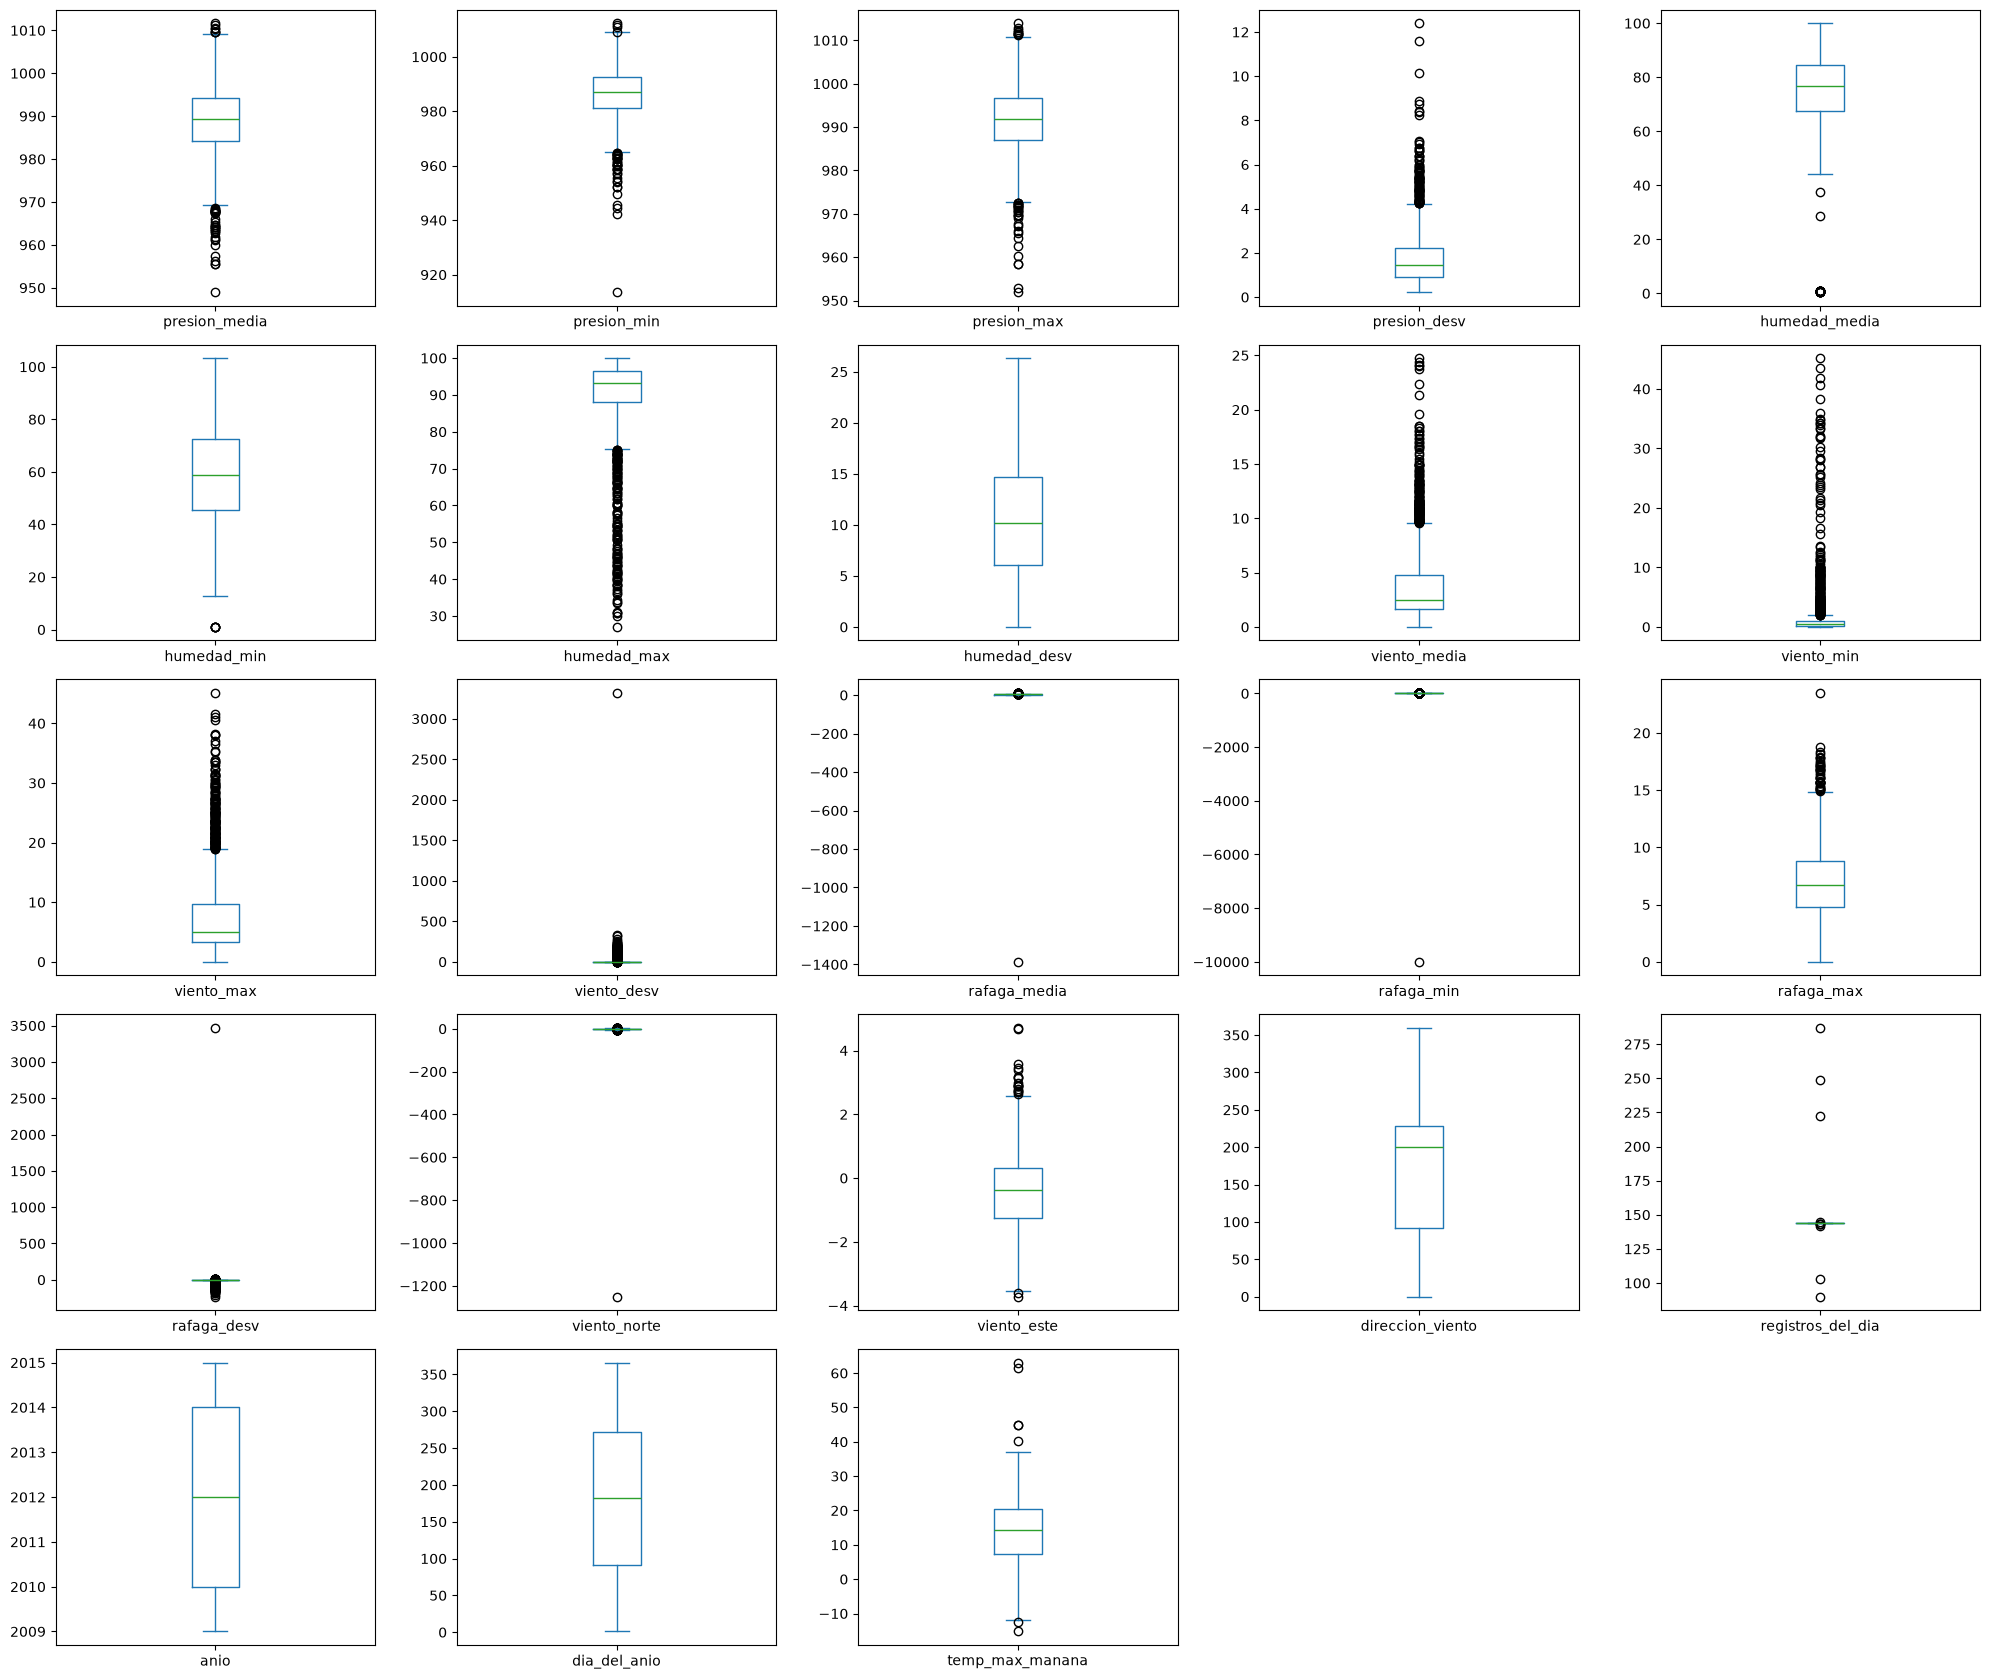

In [16]:
import matplotlib.pyplot as plt

num_cols = data.select_dtypes(include='number').columns
data[num_cols].plot(kind='box', subplots=True, layout=(6,5), figsize=(20,20))
plt.tight_layout()
plt.show()

## Análisis y decisión sobre outliers

El boxplot general muestra varias columnas con puntos alejados del resto. Antes de decidir
qué hacer, conviene distinguir dos tipos de "outlier":

1. **Errores de captura evidentes** — valores físicamente imposibles para la variable
   (ej. una ráfaga de viento negativa). Estos se eliminan, porque no representan un día real
   de clima extremo, sino un dato corrupto.
2. **Valores extremos pero físicamente plausibles** (ej. un día muy caliente o muy ventoso) —
   estos se conservan, porque son información real que el modelo debe poder aprender.

Se revisan puntualmente las variables con valores fuera de rango físico razonable.

In [17]:
# Variables que físicamente no pueden ser negativas o tienen un tope conocido
imposibles = pd.Series(False, index=data.index)

if 'rafaga_media' in data.columns:
    cond = data['rafaga_media'] < 0
    print(f"rafaga_media < 0: {cond.sum()} fila(s)")
    imposibles |= cond

if 'viento_norte' in data.columns:
    # viento_norte/viento_este son componentes de un vector de viento; el resto
    # de la columna está en un rango de un dígito (-5 a 5 aprox.), valores de
    # tres dígitos son corrupción, no viento real.
    cond = data['viento_norte'].abs() > 100
    print(f"|viento_norte| > 100: {cond.sum()} fila(s)")
    imposibles |= cond

if 'registros_del_dia' in data.columns:
    # Estación mide cada 10 min -> máximo teórico 144 registros/día
    cond = data['registros_del_dia'] > 144
    print(f"registros_del_dia > 144: {cond.sum()} fila(s)")
    imposibles |= cond

print(f"\nTotal de filas eliminadas por outliers imposibles: {imposibles.sum()} de {data.shape[0]}")
data = data[~imposibles]
print(f"Shape final tras limpieza de outliers: {data.shape}")

rafaga_media < 0: 1 fila(s)
|viento_norte| > 100: 1 fila(s)
registros_del_dia > 144: 4 fila(s)

Total de filas eliminadas por outliers imposibles: 5 de 2405
Shape final tras limpieza de outliers: (2400, 27)


## Filas sin valor de la variable objetivo

`temp_max_manana` (el target) también tenía nulos (~3.7% del dataset original, visto en la
revisión inicial de completitud) que nunca se trataron: solo se imputaron las *features* de
`X_train`/`X_test`, nunca la variable a predecir. Esto no se puede imputar — "inventar" una
etiqueta de entrenamiento introduciría información falsa que el modelo aprendería como si
fuera real. La única opción correcta es eliminar esas filas, y debe hacerse **antes** del
split para que ni entrenamiento ni test contengan observaciones sin etiqueta real.

In [18]:
print(f"Filas con temp_max_manana nulo: {data['temp_max_manana'].isna().sum()} de {data.shape[0]}")
data = data.dropna(subset=['temp_max_manana'])
print(f"Shape final: {data.shape}")

Filas con temp_max_manana nulo: 89 de 2400
Shape final: (2311, 27)


## Correlación con la variable objetivo (`temp_max_manana`)

Uno de los objetivos del laboratorio es identificar qué variables meteorológicas aportan
más a la predicción. Como primer acercamiento (antes de entrenar cualquier modelo), se
mira la correlación lineal simple de cada variable numérica con el target.

humedad_desv         0.576054
humedad_min         -0.470152
humedad_media       -0.443738
presion_desv        -0.207449
dia_del_anio         0.170048
humedad_max         -0.155580
presion_min          0.145108
presion_media        0.120290
rafaga_media        -0.117708
anio                 0.088600
presion_max          0.071896
rafaga_min          -0.063755
viento_norte        -0.054640
rafaga_desv         -0.051253
viento_media        -0.049354
viento_desv          0.048357
viento_min          -0.043566
rafaga_max           0.028248
direccion_viento     0.023353
viento_max           0.021146
registros_del_dia   -0.007750
viento_este         -0.004304
Name: temp_max_manana, dtype: float64


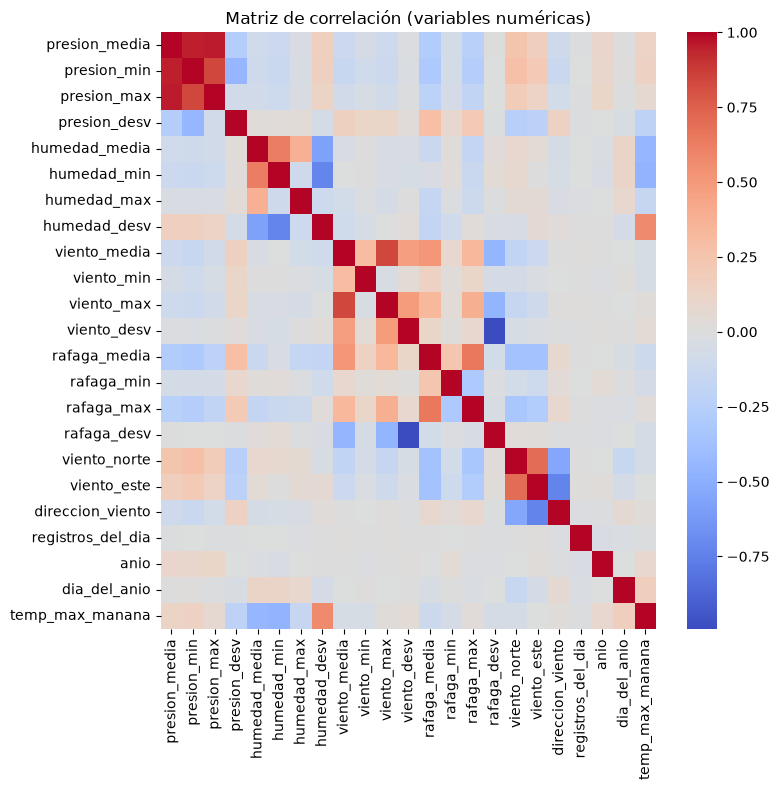

In [19]:
num_cols_target = data.select_dtypes(include='number').columns
corr_target = data[num_cols_target].corr(numeric_only=True)['temp_max_manana'].drop('temp_max_manana').sort_values(key=abs, ascending=False)
print(corr_target)

plt.figure(figsize=(8, 8))
sns.heatmap(data[num_cols_target].corr(numeric_only=True), cmap='coolwarm', center=0, annot=False)
plt.title('Matriz de correlación (variables numéricas)')
plt.tight_layout()
plt.show()

## Separación entrenamiento / prueba

Siguiendo lo indicado en el enunciado, se separa un 25% para test con `random_state=42`.
Esto se hace **ahora**, sobre los datos ya limpios (categorías normalizadas, magnitudes
corregidas, duplicados resueltos, outliers imposibles eliminados) pero **antes de imputar**
los valores faltantes restantes, precisamente para evitar la fuga de datos mencionada
antes: cualquier estadístico (mediana, moda) que se use para imputar debe calcularse
únicamente con el conjunto de entrenamiento.

In [20]:
from sklearn.model_selection import train_test_split

X = data.drop(columns=['temp_max_manana'])
y = data['temp_max_manana']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

X_train: (1733, 26) | X_test: (578, 26)


## Imputación de valores faltantes (después del split, sin fuga de datos)

Se ajusta el imputador **solo con `X_train`** y se aplica esa misma transformación a
`X_train` y `X_test`. Así, ningún valor usado para llenar huecos proviene de filas que
el modelo no debería haber visto todavía.

> Esta es la versión "manual" de la preparación, útil para seguir explorando los datos ya
> completos. Cuando se construyan los modelos (siguiente etapa: **Construcción de modelo**),
> estos mismos pasos —imputación, y lo que se agregue de codificación de categóricas o
> escalado— se deben encapsular en un `Pipeline`/`ColumnTransformer` de scikit-learn, tal
> como pide el enunciado, para que el ajuste quede automáticamente ligado a `fit()` sobre
> el conjunto de entrenamiento.

In [21]:
num_cols = X_train.select_dtypes(include=np.number).columns
cat_cols = X_train.select_dtypes(include='object').columns

print("Nulos en X_train antes de imputar:")
print(X_train.isna().sum().loc[lambda s: s > 0])

num_imputer = SimpleImputer(strategy='median').fit(X_train[num_cols])
cat_imputer = SimpleImputer(strategy='most_frequent').fit(X_train[cat_cols])

X_train = X_train.copy()
X_test = X_test.copy()

X_train[num_cols] = num_imputer.transform(X_train[num_cols])
X_train[cat_cols] = cat_imputer.transform(X_train[cat_cols])

X_test[num_cols] = num_imputer.transform(X_test[num_cols])
X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

print("\nNulos en X_train después de imputar:", X_train.isna().sum().sum())
print("Nulos en X_test después de imputar:", X_test.isna().sum().sum())

Nulos en X_train antes de imputar:
presion_media         50
presion_min           53
presion_max           46
presion_desv          64
humedad_media         52
humedad_min           46
humedad_max           56
humedad_desv          45
viento_media          63
viento_min            67
viento_max            57
viento_desv           48
rafaga_media          52
rafaga_min            46
rafaga_max            49
rafaga_desv           51
viento_norte          46
viento_este           40
direccion_viento      55
registros_del_dia     55
dia_del_anio          41
estacion_anio        169
mes                   56
sector_viento         52
dtype: int64

Nulos en X_train después de imputar: 0
Nulos en X_test después de imputar: 0


/var/folders/l9/8qd8kqn906q_s4lmvfrxlyfc0000gn/T/ipykernel_43751/3260732833.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include='object').columns


# Construcción de modelos de regresión lineal

El enunciado pide **dos** modelos con estrategias de preparación distintas, comparados con
RMSE/MAE/R². Vamos a construir **tres** (para tener más margen de comparación), en orden
creciente de complejidad y, en principio, de desempeño:

- **Modelo 1 — Básico:** solo variables numéricas, sin ingeniería de características. Sirve
  como línea base: si los modelos 2 y 3 no superan esto, algo está mal en cómo se está
  usando la información adicional.
- **Modelo 2:** incorpora las variables categóricas (`mes`, `estacion_anio`, `sector_viento`)
  mediante codificación.
- **Modelo 3:** además de lo anterior, agrega ingeniería de características (por ejemplo,
  codificación cíclica de variables temporales) para capturar mejor los patrones
  estacionales sin salirse de un modelo **lineal** (no se permiten modelos polinomiales).

Cada modelo se entrena con su propio `Pipeline` de scikit-learn — así el preprocesamiento
específico de cada estrategia queda ligado al modelo y se puede aplicar de forma consistente
tanto a test como, más adelante, al archivo de predicción final sin volver a escribir el
código de limpieza.

## Modelo 1 — Regresión lineal básica (solo variables numéricas)

**Estrategia de preparación:** usar únicamente las columnas numéricas ya limpias
(`X_train`/`X_test`), con imputación de mediana (por robustez, aunque ya no debería haber
nulos tras la preparación previa) y escalado estándar. Se descartan por completo `fecha`
(no es una variable predictiva, es un identificador temporal) y las tres columnas
categóricas (`mes`, `estacion_anio`, `sector_viento`) — precisamente porque la idea de este
modelo es ser la versión más simple posible: sin codificación de categóricas, sin
características nuevas, sin interacciones. Esto da un punto de referencia claro contra el
cual medir si el trabajo adicional de los modelos 2 y 3 realmente aporta.

In [22]:
# Columnas numéricas a usar (todo lo numérico excepto el target, que ya no está en X)
numeric_features_m1 = X_train.select_dtypes(include=np.number).columns.tolist()
print(f"Variables numéricas usadas en Modelo 1 ({len(numeric_features_m1)}):")
print(numeric_features_m1)

Variables numéricas usadas en Modelo 1 (22):
['presion_media', 'presion_min', 'presion_max', 'presion_desv', 'humedad_media', 'humedad_min', 'humedad_max', 'humedad_desv', 'viento_media', 'viento_min', 'viento_max', 'viento_desv', 'rafaga_media', 'rafaga_min', 'rafaga_max', 'rafaga_desv', 'viento_norte', 'viento_este', 'direccion_viento', 'registros_del_dia', 'anio', 'dia_del_anio']


In [23]:
# Preprocesamiento: imputar (por robustez) + escalar. Sin transformador categórico:
# ninguna columna categórica se incluye en el ColumnTransformer, así que
# quedan excluidas automáticamente del modelo (remainder='drop' por defecto).
numeric_transformer_m1 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

preprocessor_m1 = ColumnTransformer(transformers=[
    ("num", numeric_transformer_m1, numeric_features_m1),
])

pipeline_modelo1 = Pipeline(steps=[
    ("preprocesamiento", preprocessor_m1),
    ("regresor", LinearRegression()),
])

pipeline_modelo1

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesamiento', ...), ('regresor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output

In [24]:
# El pipeline completo (preprocesamiento + regresión) se ajusta con fit()
# sobre datos de entrenamiento crudos (aún con columnas categóricas y fecha):
# el propio pipeline se encarga de seleccionar y transformar solo lo que necesita.
pipeline_modelo1.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesamiento', ...), ('regresor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](26,)","['fecha','presion_media','presion_min',...,'estacion_anio','mes', 'sector_viento']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,26
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of col

### Evaluación del Modelo 1

Se calculan RMSE, MAE y R² tanto en train como en test. Comparar ambos conjuntos es
importante: si el desempeño en train es mucho mejor que en test, es señal de sobreajuste;
si son similares (como se espera de un modelo tan simple y lineal), el modelo generaliza
pero probablemente le falta información para capturar mejor la variabilidad de la
temperatura — que es justo el rol de este modelo como línea base.

In [25]:
# Función reutilizable: se usará también para los modelos 2 y 3, así queda
# lista la tabla comparativa (RMSE/MAE/R² en train y test) que pide el enunciado.
resultados_modelos = []

def evaluar_modelo(nombre, pipeline, X_train, y_train, X_test, y_test, guardar=True):
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    metricas = {
        "modelo": nombre,
        "RMSE_train": np.sqrt(mean_squared_error(y_train, y_train_pred)),
        "MAE_train": mean_absolute_error(y_train, y_train_pred),
        "R2_train": r2_score(y_train, y_train_pred),
        "RMSE_test": np.sqrt(mean_squared_error(y_test, y_test_pred)),
        "MAE_test": mean_absolute_error(y_test, y_test_pred),
        "R2_test": r2_score(y_test, y_test_pred),
    }
    if guardar:
        resultados_modelos.append(metricas)
    return metricas

metricas_modelo1 = evaluar_modelo("Modelo 1 - Básico (solo numéricas)", pipeline_modelo1, X_train, y_train, X_test, y_test)
pd.DataFrame([metricas_modelo1]).set_index("modelo")

,RMSE_train,MAE_train,R2_train,RMSE_test,MAE_test,R2_test
modelo,,,,,,
Modelo 1 - Básico (solo numéricas),6.834712,5.332623,0.4495,6.775563,5.250133,0.410842
